In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [20]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_LATENT.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X = np.load(DATA_PROCESSED / "X_windows.npy")

X.shape

(70080, 60, 6)

In [21]:
# original: (n_samples, window, n_features)
# torch conv1d: (n_samples, n_features, window)

X_cnn = np.transpose(X, (0, 2, 1)).astype(np.float32)

X_cnn.shape

(70080, 6, 60)

In [22]:
train_ratio = 0.8
n_train = int(train_ratio * len(X_cnn))

X_train = X_cnn[:n_train]
X_val = X_cnn[n_train:]

X_train_tensor = torch.tensor(X_train)
X_val_tensor = torch.tensor(X_val)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=256,
    shuffle=False
)

X_train.shape, X_val.shape

((56064, 6, 60), (14016, 6, 60))

In [23]:
class CNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        # input: (batch, n_features, 60)
        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        # compute encoded shape automatically
        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h_flat = h.view(h.size(0), -1)

        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        # ConvTranspose miatt lehet 64 hossz is, levágjuk 60-ra
        x_recon = x_recon[:, :, :self.window]

        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)

        return x_recon, mu, logvar

In [24]:
def vae_loss(x, x_recon, mu, logvar, beta=1e-3):
    recon_loss = nn.functional.mse_loss(
        x_recon,
        x,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [26]:
n_samples, n_features, window = X_cnn.shape

latent_dim = 8

model = CNNVAE(
    n_features=n_features,
    window=window,
    latent_dim=latent_dim
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model

CNNVAE(
  (encoder_conv): Sequential(
    (0): Conv1d(6, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=512, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=8, bias=True)
  (fc_decode): Linear(in_features=8, out_features=512, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 6, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
  )
)

In [27]:
n_epochs = 50
beta = 1e-3

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
}

for epoch in range(n_epochs):
    model.train()

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = model(x)

        loss, recon_loss, kl_loss = vae_loss(
            x,
            x_recon,
            mu,
            logvar,
            beta=beta
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(x)
        train_recon += recon_loss.item() * len(x)
        train_kl += kl_loss.item() * len(x)

    train_loss /= len(X_train_tensor)
    train_recon /= len(X_train_tensor)
    train_kl /= len(X_train_tensor)

    model.eval()

    val_loss = 0.0
    val_recon = 0.0
    val_kl = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)

            x_recon, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(
                x,
                x_recon,
                mu,
                logvar,
                beta=beta
            )

            val_loss += loss.item() * len(x)
            val_recon += recon_loss.item() * len(x)
            val_kl += kl_loss.item() * len(x)

    val_loss /= len(X_val_tensor)
    val_recon /= len(X_val_tensor)
    val_kl /= len(X_val_tensor)

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss: {train_loss:.6f} | "
            f"val loss: {val_loss:.6f} | "
            f"train recon: {train_recon:.6f} | "
            f"val recon: {val_recon:.6f} | "
            f"val KL: {val_kl:.6f}"
        )

Epoch 000 | train loss: 0.534163 | val loss: 0.329953 | train recon: 0.518986 | val recon: 0.308076 | val KL: 21.877004
Epoch 005 | train loss: 0.265384 | val loss: 0.280014 | train recon: 0.246582 | val recon: 0.260674 | val KL: 19.340371
Epoch 010 | train loss: 0.261375 | val loss: 0.277299 | train recon: 0.242618 | val recon: 0.257856 | val KL: 19.442233
Epoch 015 | train loss: 0.259321 | val loss: 0.277136 | train recon: 0.240599 | val recon: 0.257852 | val KL: 19.283990
Epoch 020 | train loss: 0.258127 | val loss: 0.275914 | train recon: 0.239410 | val recon: 0.256927 | val KL: 18.986452
Epoch 025 | train loss: 0.257103 | val loss: 0.275380 | train recon: 0.238416 | val recon: 0.256285 | val KL: 19.095290
Epoch 030 | train loss: 0.256443 | val loss: 0.275773 | train recon: 0.237763 | val recon: 0.256421 | val KL: 19.351258
Epoch 035 | train loss: 0.255797 | val loss: 0.275486 | train recon: 0.237125 | val recon: 0.256325 | val KL: 19.161401
Epoch 040 | train loss: 0.255250 | val l

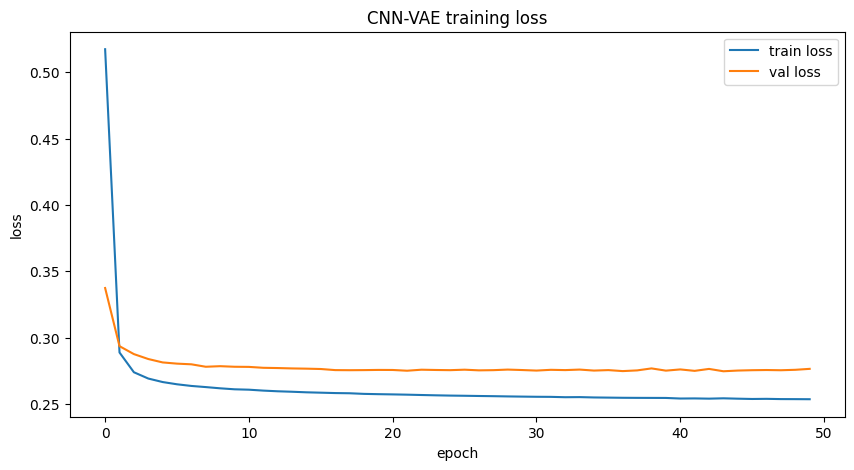

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CNN-VAE training loss")
plt.legend()
plt.show()

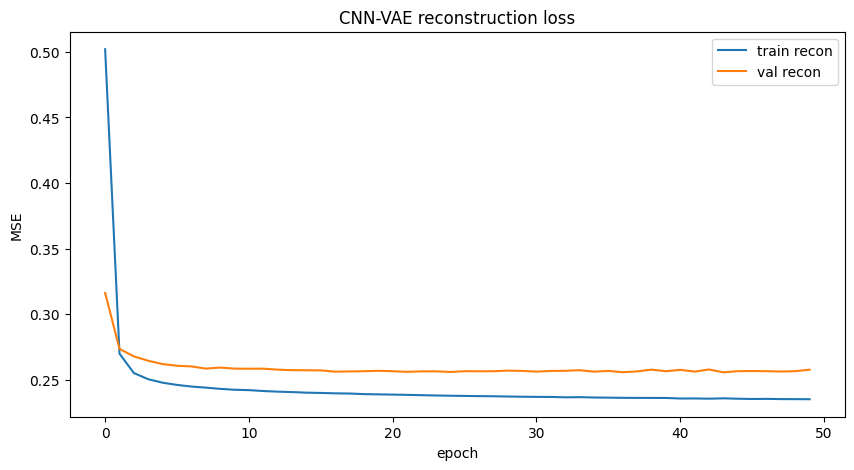

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_recon"], label="train recon")
plt.plot(history["val_recon"], label="val recon")

plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("CNN-VAE reconstruction loss")
plt.legend()
plt.show()

In [12]:
feature_names = np.load(
    DATA_PROCESSED / "feature_names.npy",
    allow_pickle=True
)

feature_names

array(['momentum_120', 'momentum_20', 'momentum_60', 'return_1d',
       'volatility_20', 'volatility_60'], dtype='<U13')

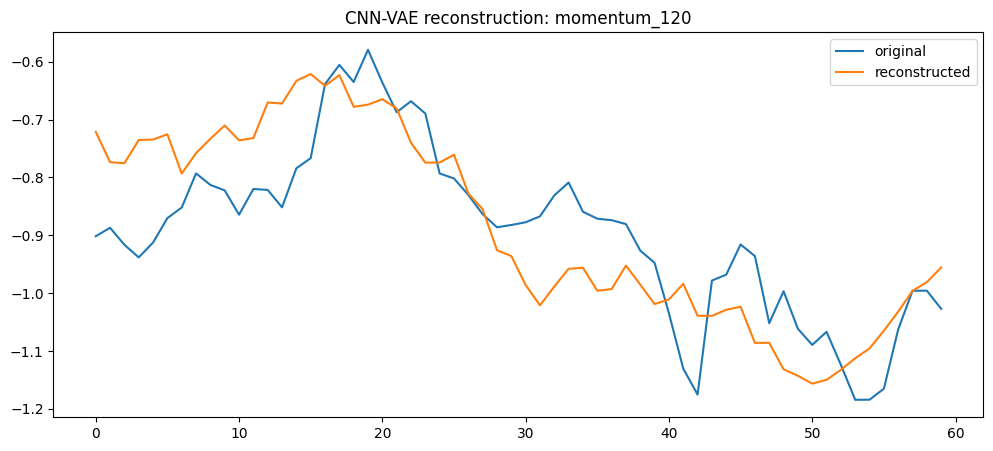

In [13]:
model.eval()

idx = 0

x = X_val_tensor[idx:idx+1].to(device)

with torch.no_grad():
    x_recon, mu, logvar = model(x)

# vissza: (features, window)
x_np = x.cpu().numpy()[0]
x_recon_np = x_recon.cpu().numpy()[0]

feature_idx = 0

plt.figure(figsize=(12, 5))

plt.plot(x_np[feature_idx], label="original")
plt.plot(x_recon_np[feature_idx], label="reconstructed")

plt.title(f"CNN-VAE reconstruction: {feature_names[feature_idx]}")
plt.legend()
plt.show()

In [14]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_features": n_features,
        "window": window,
        "latent_dim": latent_dim,
        "beta": beta,
        "history": history,
    },
    MODELS_DIR / "cnn_vae.pt"
)

In [15]:
all_loader = DataLoader(
    TensorDataset(torch.tensor(X_cnn)),
    batch_size=512,
    shuffle=False
)

Z_list = []

model.eval()

with torch.no_grad():
    for batch in all_loader:
        x = batch[0].to(device)
        mu, logvar = model.encode(x)
        Z_list.append(mu.cpu().numpy())

Z = np.concatenate(Z_list, axis=0)

Z.shape

(70080, 8)

In [16]:
np.save(DATA_LATENT / "Z_cnn_vae.npy", Z)

In [17]:
sample_dates = np.load(
    DATA_PROCESSED / "sample_dates.npy",
    allow_pickle=True
)

sample_tickers = np.load(
    DATA_PROCESSED / "sample_tickers.npy",
    allow_pickle=True
)

cnn_latent_df = pd.DataFrame(
    Z,
    columns=[f"z_{i}" for i in range(Z.shape[1])]
)

cnn_latent_df["date"] = sample_dates
cnn_latent_df["ticker"] = sample_tickers

cnn_latent_df = cnn_latent_df[
    ["date", "ticker"] + [f"z_{i}" for i in range(Z.shape[1])]
]

cnn_latent_df.head()

,date,ticker,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,0.570995,0.763362,-1.471243,0.018576,-0.514420,0.017025,-1.010024,0.101379
1,2015-09-22,AAPL,0.614655,0.792963,-1.419874,0.016469,-0.512431,0.118162,-1.057017,0.250620
2,2015-09-23,AAPL,0.658633,0.814837,-1.368775,0.034539,-0.484461,0.217649,-1.097016,0.282786
3,2015-09-24,AAPL,0.682787,0.846174,-1.320776,0.003443,-0.486795,0.370344,-1.066684,0.291002
4,2015-09-25,AAPL,0.678678,0.861573,-1.264122,-0.005995,-0.476829,0.467760,-0.986986,0.273219


In [18]:
cnn_latent_df.to_parquet(
    DATA_LATENT / "cnn_vae_latents.parquet"
)